# CNN Diagnostics

This notebook is intentionally self-contained and editable.

Current sections:
- collapse checks for the existing vanilla no-T run
- true-parameter full-resolution vs coarse diagnostics
- a plain vanilla no-T training playground for ablations

The vanilla playground below does not depend on `train_vanilla_no_T.py`.
All the model, dataset, training loop, and ablation configs live here.


In [1]:
import copy
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset

repo_root = Path.cwd().resolve()
if repo_root.name == "CNN_diagnostics":
    repo_root = repo_root.parent
if not (repo_root / "produce_data.py").exists():
    raise RuntimeError(f"Could not locate project root from {Path.cwd()}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from produce_data import simulate_xpcs

metadata_path = repo_root / "models/Vanilla_XPCS_no_T_best_20260413-180715.json"
summary_path = repo_root / (
    "results/vanilla_noT_vanseed42_top-left_20260413-183719/"
    "sim_reconstruction_vanilla/summary.csv"
)
non_eq_manifest_path = repo_root / "dataset/simulation/manifest_with_non_equ.csv"
dataset_root = repo_root / "dataset/simulation"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with metadata_path.open("r", encoding="utf-8") as handle:
    metadata = json.load(handle)

summary_df = pd.read_csv(summary_path)
summary_df["path_abs"] = summary_df["path"].map(lambda p: repo_root / p)

repo_root, device, dataset_root


(PosixPath('/data1/bowenyu/XPCS_ODE'),
 device(type='cuda'),
 PosixPath('/data1/bowenyu/XPCS_ODE/dataset/simulation'))

In [2]:
manifest_path = repo_root / metadata["dataset_root"] / "manifest.csv"
manifest_df = pd.read_csv(manifest_path)

train_ids = set(metadata["train_ids"])
test_ids = set(metadata["test_ids"])
train_df = manifest_df[manifest_df["id"].isin(train_ids)].copy()
test_df = manifest_df[manifest_df["id"].isin(test_ids)].copy()

baseline_rows = []
for baseline_name, predictor in {
    "train_mean": {
        "gamma": float(train_df["gamma"].mean()),
        "D": float(train_df["D"].mean()),
        "GB_conc": float(train_df["GB_conc"].mean()),
    },
    "train_median": {
        "gamma": float(train_df["gamma"].median()),
        "D": float(train_df["D"].median()),
        "GB_conc": float(train_df["GB_conc"].median()),
    },
    "range_center": {
        "gamma": 0.5 * (2e18 + 5e18),
        "D": float(np.sqrt(1e-23 * 1e-21)),
        "GB_conc": 0.15,
    },
}.items():
    row = {
        "baseline": baseline_name,
        "gamma_pred": predictor["gamma"],
        "D_pred": predictor["D"],
        "GB_conc_pred": predictor["GB_conc"],
    }
    for key in ["gamma", "D", "GB_conc"]:
        err = test_df[key].to_numpy(dtype=float) - predictor[key]
        row[f"{key}_mae"] = float(np.mean(np.abs(err)))
        row[f"{key}_rmse"] = float(np.sqrt(np.mean(err ** 2)))
    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)
baseline_df


,baseline,gamma_pred,D_pred,GB_conc_pred,gamma_mae,gamma_rmse,D_mae,D_rmse,GB_conc_mae,GB_conc_rmse
0,train_mean,3.494538e+18,2.136454e-22,0.149806,7.445503e+17,8.591207e+17,1.886913e-22,2.454816e-22,0.074720,0.085907
1,train_median,3.509504e+18,9.756076e-23,0.149758,7.447276e+17,8.586185e+17,1.754218e-22,2.743344e-22,0.074722,0.085908
2,range_center,3.500000e+18,1.000000e-22,0.150000,7.445867e+17,8.589072e+17,1.751849e-22,2.732527e-22,0.074712,0.085903


In [3]:
collapse_rows = []
for key in ["gamma", "D", "GB_conc"]:
    collapse_rows.append({
        "parameter": key,
        "pred_mean": float(summary_df[f"{key}_pred"].mean()),
        "pred_std": float(summary_df[f"{key}_pred"].std(ddof=1)),
        "true_mean": float(summary_df[f"{key}_true"].mean()),
        "true_std": float(summary_df[f"{key}_true"].std(ddof=1)),
        "abs_error_mean": float(summary_df[f"{key}_abs_error"].mean()),
    })

collapse_df = pd.DataFrame(collapse_rows)
collapse_df


,parameter,pred_mean,pred_std,true_mean,true_std,abs_error_mean
0,gamma,3.491292e+18,7.117385e+15,3.160183e+18,6.534454e+17,5.364696e+17
1,D,9.866596e-23,1.130609e-24,1.436428e-22,2.382873e-22,1.557227e-22
2,GB_conc,1.491069e-01,7.525232e-04,1.877531e-01,1.279965e-01,1.093374e-01


## True-Parameter Quartile Check

The next cell reads one csv with `nonequilibrium_measure`, picks one representative sample from each quartile, and then compares:

- saved coarse-grained spectrum
- true params -> full-resolution simulation
- true params -> full-resolution simulation -> coarse-grained back to `256 x 256`

Important: the saved `.pt` tensors are raw coarse `g2`, not re-normalized to `[1.0, 1.2]`.
So the comparison below stays in raw space for the metrics, and only uses a shared color scale for display.


In [4]:
def coarse_grain_g2_local(g2, target_size=(256, 256)):
    if g2.ndim == 2:
        g2 = g2.unsqueeze(0).unsqueeze(0)
    elif g2.ndim == 3:
        g2 = g2.unsqueeze(0)
    return F.interpolate(g2, size=target_size, mode="bilinear", align_corners=False).squeeze()

# restrict_to_test_split = True
# non_eq_df = pd.read_csv(non_eq_manifest_path)
# non_eq_df["path_abs"] = non_eq_df["path"].map(lambda p: repo_root / p)
# if restrict_to_test_split:
#     non_eq_df = non_eq_df[non_eq_df["id"].isin(test_ids)].copy()
# non_eq_df = non_eq_df.sort_values("nonequilibrium_measure").reset_index(drop=True)

# selected_rows = []
# n_rows = len(non_eq_df)
# for quartile_idx in range(4):
#     start = int(quartile_idx * n_rows / 4)
#     end = int((quartile_idx + 1) * n_rows / 4)
#     quartile_slice = non_eq_df.iloc[start:end].copy()
#     representative = quartile_slice.iloc[len(quartile_slice) // 2]
#     selected_rows.append(representative)
# selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)
# selected_df[["id", "nonequilibrium_measure", "gamma", "D", "GB_conc", "T"]]

# metrics_rows = []
# fig, axes = plt.subplots(len(selected_df), 3, figsize=(16, 4.5 * len(selected_df)), constrained_layout=True)
# if len(selected_df) == 1:
#     axes = np.array([axes])

# for row_idx, (_, row) in enumerate(selected_df.iterrows()):
#     original_coarse = torch.load(row["path_abs"], weights_only=True).to(torch.float32).squeeze(0)
#     true_full = simulate_xpcs(
#         gamma=float(row["gamma"]),
#         D=float(row["D"]),
#         GB_conc=float(row["GB_conc"]),
#         T=float(row["T"]),
#         seed=42,
#         coarse=False,
#     )
#     if true_full is None:
#         raise RuntimeError(f"simulate_xpcs returned None for id={row['id']}")
#     true_full = true_full.to(torch.float32)
#     true_coarse = coarse_grain_g2_local(true_full, target_size=(256, 256))

#     coarse_mse = float(torch.mean((original_coarse - true_coarse) ** 2))
#     coarse_mae = float(torch.mean(torch.abs(original_coarse - true_coarse)))
#     metrics_rows.append({
#         "quartile": row_idx + 1,
#         "id": int(row["id"]),
#         "nonequilibrium_measure": float(row["nonequilibrium_measure"]),
#         "coarse_mse": coarse_mse,
#         "coarse_mae": coarse_mae,
#     })

#     row_axes = axes[row_idx]
#     coarse_vmin = float(torch.min(torch.stack([original_coarse.min(), true_coarse.min()])))
#     coarse_vmax = float(torch.max(torch.stack([original_coarse.max(), true_coarse.max()])))
#     full_vmin = float(true_full.min())
#     full_vmax = float(true_full.max())
#     for ax, matrix, title, vmin, vmax in [
#         (row_axes[0], original_coarse, f"Q{row_idx + 1} saved coarse | id={int(row['id'])}", coarse_vmin, coarse_vmax),
#         (row_axes[1], true_coarse, f"Q{row_idx + 1} true params -> coarse | mse={coarse_mse:.2e}", coarse_vmin, coarse_vmax),
#         (row_axes[2], true_full, f"Q{row_idx + 1} true params -> full-res", full_vmin, full_vmax),
#     ]:
#         image = ax.imshow(matrix.detach().cpu().numpy(), origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
#         ax.set_title(title)
#         ax.set_xlabel("Time $t_1$")
#         ax.set_ylabel("Time $t_2$")
#         fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

# plt.show()
# pd.DataFrame(metrics_rows)


## Vanilla No-T Playground

Everything below is a plain notebook version of the vanilla no-T model.

What you can change easily:
- input normalization: `per_sample_minmax` or `global_zscore`
- whether to mask the diagonal
- learning rate, epochs, batch size
- train subset size for cheap quick tests

The baseline config called `baseline_current` matches the current training file behavior.


In [5]:
def normalize_g2_local(g2, min_val=1.0, max_val=1.2):
    g2_min = g2.min()
    g2_max = g2.max()
    return (g2 - g2_min) / (g2_max - g2_min + 1e-8) * (max_val - min_val) + min_val


def norm_from_meta(y_raw, norm_meta, eps=1e-30):
    if y_raw.ndim == 1:
        y_raw = y_raw.unsqueeze(0)
        squeeze_back = True
    else:
        squeeze_back = False
    y_out = torch.empty_like(y_raw)
    for j, key in enumerate(["gamma", "D", "GB_conc"]):
        low = float(norm_meta[key]["low"])
        high = float(norm_meta[key]["high"])
        scale = norm_meta[key].get("scale", "linear")
        if scale == "log":
            y_out[:, j] = (
                (torch.log10(torch.clamp(y_raw[:, j], min=eps)) - np.log10(low))
                / (np.log10(high) - np.log10(low))
            )
        else:
            y_out[:, j] = (y_raw[:, j] - low) / (high - low)
    if squeeze_back:
        y_out = y_out.squeeze(0)
    return y_out


def denorm_from_meta(y_norm, norm_meta):
    if y_norm.ndim == 1:
        y_norm = y_norm.unsqueeze(0)
        squeeze_back = True
    else:
        squeeze_back = False
    y_out = torch.empty_like(y_norm)
    for j, key in enumerate(["gamma", "D", "GB_conc"]):
        low = float(norm_meta[key]["low"])
        high = float(norm_meta[key]["high"])
        scale = norm_meta[key].get("scale", "linear")
        if scale == "log":
            y_out[:, j] = low * 10 ** (y_norm[:, j] * (np.log10(high) - np.log10(low)))
        else:
            y_out[:, j] = low + y_norm[:, j] * (high - low)
    if squeeze_back:
        y_out = y_out.squeeze(0)
    return y_out


class NotebookXPCSDataset(Dataset):
    def __init__(self, frame, repo_root, input_normalization, mask_diagonal, global_mean, global_std):
        self.frame = frame.reset_index(drop=True).copy()
        self.repo_root = repo_root
        self.input_normalization = input_normalization
        self.mask_diagonal = mask_diagonal
        self.global_mean = float(global_mean)
        self.global_std = float(global_std)
        self.norm_meta = {
            "gamma": {"low": 2e18, "high": 5e18, "scale": "linear"},
            "D": {"low": 1e-23, "high": 1e-21, "scale": "log"},
            "GB_conc": {"low": 0.0, "high": 0.3, "scale": "linear"},
        }
        self.diag_mask = torch.ones(1, 256, 256, dtype=torch.float32)
        self.diag_mask[0, range(256), range(256)] = 0.0

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        path = Path(row["path"])
        if not path.is_absolute():
            path = self.repo_root / path
        x = torch.load(path, weights_only=True).to(torch.float32).squeeze(0)
        if self.input_normalization == "per_sample_minmax":
            x = normalize_g2_local(x, min_val=1.0, max_val=1.2)
        elif self.input_normalization == "global_zscore":
            x = (x - self.global_mean) / (self.global_std + 1e-6)
        else:
            raise ValueError("unknown input_normalization")
        if x.ndim == 2:
            x = x.unsqueeze(0)
        if self.mask_diagonal:
            x = x * self.diag_mask
        y_raw = torch.tensor([row["gamma"], row["D"], row["GB_conc"]], dtype=torch.float32)
        y_norm = norm_from_meta(y_raw, self.norm_meta)
        return x, y_norm, y_raw


class NotebookVanillaNoT(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm_meta = {
            "gamma": {"low": 2e18, "high": 5e18, "scale": "linear"},
            "D": {"low": 1e-23, "high": 1e-21, "scale": "log"},
            "GB_conc": {"low": 0.0, "high": 0.3, "scale": "linear"},
        }
        self.conv_net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.predictor = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        features = self.conv_net(x)
        return self.predictor(features)


In [6]:
simulation_manifest = pd.read_csv(dataset_root / "manifest.csv")

ablation_configs = [
    {
        "name": "baseline_current",
        "input_normalization": "per_sample_minmax",
        "mask_diagonal": True,
        "batch_size": 128,
        "epochs": 100,
        "learning_rate": 3e-4,
        "patience": 20,
        "seed": 42,
        "subset_size": None,
    },
    # {
    #     "name": "no_diag_mask",
    #     "input_normalization": "per_sample_minmax",
    #     "mask_diagonal": False,
    #     "batch_size": 32,
    #     "epochs": 100,
    #     "learning_rate": 1e-3,
    #     "patience": 15,
    #     "seed": 42,
    #     "subset_size": None,
    # },
    {
        "name": "global_zscore",
        "input_normalization": "global_zscore",
        "mask_diagonal": True,
        "batch_size": 128,
        "epochs": 100,
        "learning_rate": 3e-4,
        "patience": 20,
        "seed": 42,
        "subset_size": None,
    },
    # {
    #     "name": "global_zscore_no_diag",
    #     "input_normalization": "global_zscore",
    #     "mask_diagonal": False,
    #     "batch_size": 32,
    #     "epochs": 100,
    #     "learning_rate": 1e-3,
    #     "patience": 15,
    #     "seed": 42,
    #     "subset_size": None,
    # },
]

pd.DataFrame(ablation_configs)


,name,input_normalization,mask_diagonal,batch_size,epochs,learning_rate,patience,seed,subset_size
0,baseline_current,per_sample_minmax,True,128,100,0.0003,20,42,None
1,global_zscore,global_zscore,True,128,100,0.0003,20,42,None


In [7]:
def run_vanilla_ablation(config):
    random.seed(config["seed"])
    np.random.seed(config["seed"])
    torch.manual_seed(config["seed"])
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(config["seed"])

    frame = simulation_manifest.copy().reset_index(drop=True)
    if config["subset_size"] is not None:
        frame = frame.sample(n=config["subset_size"], random_state=config["seed"]).reset_index(drop=True)

    permutation = np.random.default_rng(config["seed"]).permutation(len(frame))
    train_size = int(0.7 * len(frame))
    val_size = int(0.15 * len(frame))
    train_idx = permutation[:train_size]
    val_idx = permutation[train_size:train_size + val_size]
    test_idx = permutation[train_size + val_size:]

    train_frame = frame.iloc[train_idx].copy().reset_index(drop=True)
    val_frame = frame.iloc[val_idx].copy().reset_index(drop=True)
    test_frame = frame.iloc[test_idx].copy().reset_index(drop=True)

    global_mean = 1.1315594972968084
    global_std = 0.011241361147397289

    train_dataset = NotebookXPCSDataset(
        train_frame,
        repo_root=repo_root,
        input_normalization=config["input_normalization"],
        mask_diagonal=config["mask_diagonal"],
        global_mean=global_mean,
        global_std=global_std,
    )
    val_dataset = NotebookXPCSDataset(
        val_frame,
        repo_root=repo_root,
        input_normalization=config["input_normalization"],
        mask_diagonal=config["mask_diagonal"],
        global_mean=global_mean,
        global_std=global_std,
    )
    test_dataset = NotebookXPCSDataset(
        test_frame,
        repo_root=repo_root,
        input_normalization=config["input_normalization"],
        mask_diagonal=config["mask_diagonal"],
        global_mean=global_mean,
        global_std=global_std,
    )

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False)

    model = NotebookVanillaNoT().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    scheduler = CosineAnnealingLR(optimizer, T_max=config["epochs"])

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0
    history_rows = []

    for epoch in range(config["epochs"]):
        model.train()
        train_loss_sum = 0.0
        train_count = 0
        for x, y_norm, _ in train_loader:
            x = x.to(device)
            y_norm = y_norm.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = F.mse_loss(pred, y_norm)
            loss.backward()
            optimizer.step()
            train_loss_sum += float(loss.item()) * x.size(0)
            train_count += x.size(0)

        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        val_pred_sum = torch.zeros(3, device=device)
        val_pred_sq_sum = torch.zeros(3, device=device)
        val_target_sum = torch.zeros(3, device=device)
        val_target_sq_sum = torch.zeros(3, device=device)
        val_mae_raw_sum = torch.zeros(3, device=device)
        with torch.no_grad():
            for x, y_norm, y_raw in val_loader:
                x = x.to(device)
                y_norm = y_norm.to(device)
                y_raw = y_raw.to(device)
                pred = model(x)
                loss = F.mse_loss(pred, y_norm)
                pred_raw = denorm_from_meta(pred, train_dataset.norm_meta)
                val_loss_sum += float(loss.item()) * x.size(0)
                val_count += x.size(0)
                val_pred_sum += pred.sum(dim=0)
                val_pred_sq_sum += (pred ** 2).sum(dim=0)
                val_target_sum += y_norm.sum(dim=0)
                val_target_sq_sum += (y_norm ** 2).sum(dim=0)
                val_mae_raw_sum += (pred_raw - y_raw).abs().sum(dim=0)

        train_loss = train_loss_sum / train_count
        val_loss = val_loss_sum / val_count
        val_pred_mean = val_pred_sum / val_count
        val_pred_std = torch.sqrt(torch.clamp(val_pred_sq_sum / val_count - val_pred_mean ** 2, min=0.0))
        val_target_mean = val_target_sum / val_count
        val_target_std = torch.sqrt(torch.clamp(val_target_sq_sum / val_count - val_target_mean ** 2, min=0.0))
        val_mae_raw = val_mae_raw_sum / val_count

        history_rows.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "pred_std_gamma": float(val_pred_std[0]),
            "pred_std_D": float(val_pred_std[1]),
            "pred_std_GB_conc": float(val_pred_std[2]),
            "target_std_gamma": float(val_target_std[0]),
            "target_std_D": float(val_target_std[1]),
            "target_std_GB_conc": float(val_target_std[2]),
            "val_mae_gamma": float(val_mae_raw[0]),
            "val_mae_D": float(val_mae_raw[1]),
            "val_mae_GB_conc": float(val_mae_raw[2]),
        })

        if (epoch + 1) == 1 or (epoch + 1) % 10 == 0 or epoch == config["epochs"] - 1:
            print(
                f"[{config['name']}] epoch {epoch + 1:03d} "
                f"train={train_loss:.6f} val={val_loss:.6f} "
                f"pred_std=({val_pred_std[0]:.4f}, {val_pred_std[1]:.4f}, {val_pred_std[2]:.4f}) "
                f"target_std=({val_target_std[0]:.4f}, {val_target_std[1]:.4f}, {val_target_std[2]:.4f})"
            )

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= config["patience"]:
                break
        scheduler.step()

    model.load_state_dict(best_state)
    model.eval()

    test_loss_sum = 0.0
    test_count = 0
    test_mae_raw_sum = torch.zeros(3, device=device)
    test_pred_sum = torch.zeros(3, device=device)
    test_pred_sq_sum = torch.zeros(3, device=device)
    with torch.no_grad():
        for x, y_norm, y_raw in test_loader:
            x = x.to(device)
            y_norm = y_norm.to(device)
            y_raw = y_raw.to(device)
            pred = model(x)
            pred_raw = denorm_from_meta(pred, train_dataset.norm_meta)
            test_loss_sum += float(F.mse_loss(pred, y_norm).item()) * x.size(0)
            test_count += x.size(0)
            test_mae_raw_sum += (pred_raw - y_raw).abs().sum(dim=0)
            test_pred_sum += pred.sum(dim=0)
            test_pred_sq_sum += (pred ** 2).sum(dim=0)

    test_loss = test_loss_sum / test_count
    test_mae_raw = test_mae_raw_sum / test_count
    test_pred_mean = test_pred_sum / test_count
    test_pred_std = torch.sqrt(torch.clamp(test_pred_sq_sum / test_count - test_pred_mean ** 2, min=0.0))

    constant_rows = []
    for baseline_name, predictor in {
        "train_mean": {
            "gamma": float(train_frame["gamma"].mean()),
            "D": float(train_frame["D"].mean()),
            "GB_conc": float(train_frame["GB_conc"].mean()),
        },
        "train_median": {
            "gamma": float(train_frame["gamma"].median()),
            "D": float(train_frame["D"].median()),
            "GB_conc": float(train_frame["GB_conc"].median()),
        },
        "range_center": {
            "gamma": 0.5 * (2e18 + 5e18),
            "D": float(np.sqrt(1e-23 * 1e-21)),
            "GB_conc": 0.15,
        },
    }.items():
        row = {"baseline": baseline_name}
        for key in ["gamma", "D", "GB_conc"]:
            err = test_frame[key].to_numpy(dtype=float) - predictor[key]
            row[f"{key}_mae"] = float(np.mean(np.abs(err)))
        constant_rows.append(row)
    constant_df = pd.DataFrame(constant_rows)

    result_row = {
        "name": config["name"],
        "input_normalization": config["input_normalization"],
        "mask_diagonal": config["mask_diagonal"],
        "subset_size": config["subset_size"],
        "epochs_requested": config["epochs"],
        "epochs_ran": len(history_rows),
        "best_val_loss": best_val_loss,
        "test_loss": test_loss,
        "test_mae_gamma": float(test_mae_raw[0]),
        "test_mae_D": float(test_mae_raw[1]),
        "test_mae_GB_conc": float(test_mae_raw[2]),
        "test_pred_std_gamma": float(test_pred_std[0]),
        "test_pred_std_D": float(test_pred_std[1]),
        "test_pred_std_GB_conc": float(test_pred_std[2]),
        "constant_train_mean_gamma_mae": float(constant_df.loc[constant_df['baseline'] == 'train_mean', 'gamma_mae'].iloc[0]),
        "constant_train_mean_D_mae": float(constant_df.loc[constant_df['baseline'] == 'train_mean', 'D_mae'].iloc[0]),
        "constant_train_mean_GB_conc_mae": float(constant_df.loc[constant_df['baseline'] == 'train_mean', 'GB_conc_mae'].iloc[0]),
        "constant_range_center_gamma_mae": float(constant_df.loc[constant_df['baseline'] == 'range_center', 'gamma_mae'].iloc[0]),
        "constant_range_center_D_mae": float(constant_df.loc[constant_df['baseline'] == 'range_center', 'D_mae'].iloc[0]),
        "constant_range_center_GB_conc_mae": float(constant_df.loc[constant_df['baseline'] == 'range_center', 'GB_conc_mae'].iloc[0]),
    }

    return {
        "config": config,
        "model": model,
        "history": pd.DataFrame(history_rows),
        "summary": pd.DataFrame([result_row]),
        "constant_baselines": constant_df,
        "train_frame": train_frame,
        "val_frame": val_frame,
        "test_frame": test_frame,
    }


In [8]:
selected_names = [
    "baseline_current",
    # "no_diag_mask",
    "global_zscore",
    # "global_zscore_no_diag",
]

quick_override = {
    "epochs": 20,
    "subset_size": 512,
}

ablation_runs = {}
summary_rows = []
for config in ablation_configs:
    if config["name"] not in selected_names:
        continue
    run_config = dict(config)
    # run_config.update(quick_override)
    print("=" * 80)
    print("Running", run_config)
    result = run_vanilla_ablation(run_config)
    ablation_runs[run_config["name"]] = result
    summary_rows.append(result["summary"].iloc[0].to_dict())

ablation_summary_df = pd.DataFrame(summary_rows)
ablation_summary_df


Running {'name': 'baseline_current', 'input_normalization': 'per_sample_minmax', 'mask_diagonal': True, 'batch_size': 128, 'epochs': 100, 'learning_rate': 0.0003, 'patience': 20, 'seed': 42, 'subset_size': None}
[baseline_current] epoch 001 train=0.322860 val=0.184781 pred_std=(0.0019, 0.0017, 0.0016) target_std=(0.2904, 0.2995, 0.2861)
[baseline_current] epoch 010 train=0.084365 val=0.086034 pred_std=(0.0037, 0.0038, 0.0037) target_std=(0.2904, 0.2995, 0.2861)
[baseline_current] epoch 020 train=0.084279 val=0.086025 pred_std=(0.0037, 0.0036, 0.0035) target_std=(0.2904, 0.2995, 0.2861)
[baseline_current] epoch 030 train=0.084702 val=0.086634 pred_std=(0.0036, 0.0037, 0.0037) target_std=(0.2904, 0.2995, 0.2861)
[baseline_current] epoch 040 train=0.084665 val=0.086073 pred_std=(0.0034, 0.0035, 0.0034) target_std=(0.2904, 0.2995, 0.2861)
[baseline_current] epoch 050 train=0.084370 val=0.086048 pred_std=(0.0034, 0.0033, 0.0032) target_std=(0.2904, 0.2995, 0.2861)
[baseline_current] epoch 0

,name,input_normalization,mask_diagonal,subset_size,epochs_requested,epochs_ran,best_val_loss,test_loss,test_mae_gamma,test_mae_D,test_mae_GB_conc,test_pred_std_gamma,test_pred_std_D,test_pred_std_GB_conc,constant_train_mean_gamma_mae,constant_train_mean_D_mae,constant_train_mean_GB_conc_mae,constant_range_center_gamma_mae,constant_range_center_D_mae,constant_range_center_GB_conc_mae
0,baseline_current,per_sample_minmax,True,None,100,88,0.085918,0.081892,7.440047e+17,1.762589e-22,0.075143,0.003049,0.003027,0.002965,7.445503e+17,1.886913e-22,0.07472,7.445867e+17,1.751849e-22,0.074712
1,global_zscore,global_zscore,True,None,100,100,0.030742,0.031935,7.315223e+17,1.817233e-23,0.028496,0.046547,0.278888,0.246234,7.445503e+17,1.886913e-22,0.07472,7.445867e+17,1.751849e-22,0.074712


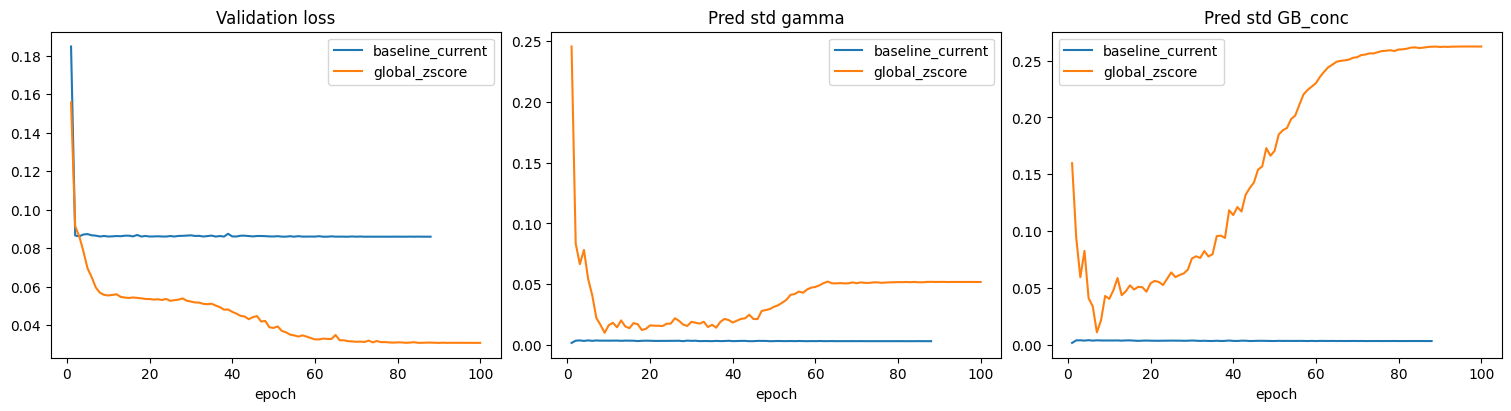

In [9]:
if ablation_runs:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for name, result in ablation_runs.items():
        history = result["history"]
        axes[0].plot(history["epoch"], history["val_loss"], label=name)
        axes[1].plot(history["epoch"], history["pred_std_gamma"], label=name)
        axes[2].plot(history["epoch"], history["pred_std_GB_conc"], label=name)
    axes[0].set_title("Validation loss")
    axes[1].set_title("Pred std gamma")
    axes[2].set_title("Pred std GB_conc")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.legend()
    plt.show()
